# Lightweight Single-Image Super-Resolution with IMDN-Lite
### Deep Learning Project | Ablation Study: Training Duration
**Student A -- Model and Implementation Lead**

This notebook implements and evaluates IMDN-Lite (Hui et al., 2019), a lightweight
single-image super-resolution model targeting x2 upscaling on CPU-constrained hardware.

The notebook runs two trials back-to-back using the same combined patch dataset and
identical hyperparameters. The only variable is the training budget:

| Trial | max_steps | Purpose |
|-------|-----------|---------|
| Trial 1 | 100 | Short training run |
| Trial 2 | 200 | Extended training run |

Comparing the two trials answers the question: does training longer on this dataset
and architecture yield a meaningful improvement in PSNR and SSIM?

**Dataset.** The teammate prepared two sets of pre-cut patch pairs from DIV2K
(Agustsson and Timofte, 2017) at scale x2. Each patch is stored as a float32
`.npy` array with pixel values in [0, 1]. LR patches are 48x48 and HR patches
are 96x96. Both subsets are combined via `ConcatDataset` before training.


## Section 0 -- Environment Setup

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import time
import random
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import structural_similarity as sk_ssim

print(f"PyTorch version : {torch.__version__}")
print("Device          : CPU (GPU not assumed -- project requirement)")
print("All imports loaded successfully.")


PyTorch version : 2.12.0+cpu
Device          : CPU (GPU not assumed -- project requirement)
All imports loaded successfully.


## Section 1 -- Reproducibility and Shared Configuration

All hyperparameters that are common to both trials are defined here. The only
parameter that changes between trials is `max_steps`, which is set individually
per trial in Section 6.


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Seed fixed to {seed}.")

set_seed(42)


Seed fixed to 42.


### 1.2 Shared Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `scale` | 2 | Standard x2 SR benchmark |
| `hr_patch_size` | 96 | Fixed by the pre-cut .npy patches |
| `lr_patch_size` | 48 | Fixed by the pre-cut .npy patches (hr / scale) |
| `batch_size` | 16 | Fits comfortably in CPU RAM |
| `num_features` | 32 | Lightweight: paper uses 64; halved for CPU deployment |
| `num_blocks` | 3 | Paper uses 6; halved for the same reason |
| `learning_rate` | 2e-4 | Adam default for SR tasks (Hui et al., 2019) |
| `lr_decay_steps` | 400 | Halve LR at this step interval |
| `lr_decay_factor` | 0.5 | Halve LR at each milestone |
| `grad_clip` | 1.0 | Prevents gradient explosion on small batches |

`max_steps` is intentionally absent here -- it is set per trial.


In [4]:
BASE_CONFIG = {
    "scale"           : 2,
    "hr_patch_size"   : 96,
    "lr_patch_size"   : 48,
    "num_features"    : 32,
    "num_blocks"      : 3,
    "batch_size"      : 16,
    "learning_rate"   : 2e-4,
    "lr_decay_steps"  : 400,
    "lr_decay_factor" : 0.5,
    "grad_clip"       : 1.0,
    "seed"            : 42,
}

TRIALS = [
    {"name": "trial_100_steps", "max_steps": 100},
    {"name": "trial_200_steps", "max_steps": 200},
]

print("Shared configuration:")
print(json.dumps(BASE_CONFIG, indent=2))
print(f"\nTrials to run: {[t['name'] for t in TRIALS]}")


Shared configuration:
{
  "scale": 2,
  "hr_patch_size": 96,
  "lr_patch_size": 48,
  "num_features": 32,
  "num_blocks": 3,
  "batch_size": 16,
  "learning_rate": 0.0002,
  "lr_decay_steps": 400,
  "lr_decay_factor": 0.5,
  "grad_clip": 1.0,
  "seed": 42
}

Trials to run: ['trial_100_steps', 'trial_200_steps']


## Section 2 -- Data Pipeline

The teammate prepared two sets of pre-cut `.npy` patch pairs. Both subsets are
combined with `ConcatDataset`, which presents them as a single seamless dataset.
The combined dataset is shared by both trials.

| Class | Purpose | Output shape |
|-------|---------|--------------|
| `PatchDataset` | Loads pre-cut .npy patch pairs for training | LR `[3, 48, 48]`, HR `[3, 96, 96]` |
| `ValDataset` | Loads pre-cut .npy patch pairs for validation | LR `[3, 48, 48]`, HR `[3, 96, 96]`, filename |


### 2.1 Data Paths

In [5]:
BASE1 = Path(r'C:\Users\DPQUAI250142\Desktop\DL_project\patch_dataset\patch_dataset')
BASE2 = Path(r'C:\Users\DPQUAI250142\Desktop\DL_project\patches_Dataset')

for p in [BASE1 / 'train' / 'hr', BASE1 / 'train' / 'lr',
          BASE1 / 'val'   / 'hr', BASE1 / 'val'   / 'lr',
          BASE2 / 'train' / 'hr', BASE2 / 'train' / 'lr',
          BASE2 / 'val'   / 'hr', BASE2 / 'val'   / 'lr']:
    if not p.exists():
        print(f"WARNING -- path not found: {p}")
    else:
        n = len(list(p.glob('*.npy')))
        print(f"OK  {p}  ({n} .npy files)")


OK  C:\Users\DPQUAI250142\Desktop\DL_project\patch_dataset\patch_dataset\train\hr  (18268 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patch_dataset\patch_dataset\train\lr  (18268 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patch_dataset\patch_dataset\val\hr  (10 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patch_dataset\patch_dataset\val\lr  (10 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patches_Dataset\train\hr  (98646 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patches_Dataset\train\lr  (98646 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patches_Dataset\val\hr  (10 .npy files)
OK  C:\Users\DPQUAI250142\Desktop\DL_project\patches_Dataset\val\lr  (10 .npy files)


### 2.2 Dataset Classes

In [6]:
class PatchDataset(Dataset):
    """
    Loads pre-cut LR/HR patch pairs stored as .npy files.
    Each .npy file is a float32 array of shape (H, W, 3) with values in [0, 1].
    Files are paired by sorted order. Any corrupt file silently falls back to
    the next valid index so that training is not interrupted.
    """

    def __init__(self, hr_dir, lr_dir):
        all_hr = sorted(Path(hr_dir).glob('*.npy'))
        all_lr = sorted(Path(lr_dir).glob('*.npy'))
        self.hr_paths, self.lr_paths = [], []
        missing = 0
        for h, l in zip(all_hr, all_lr):
            if h.exists() and l.exists():
                self.hr_paths.append(h)
                self.lr_paths.append(l)
            else:
                missing += 1
        if missing > 0:
            print(f"PatchDataset: skipped {missing} missing pairs in {hr_dir}")
        assert len(self.hr_paths) > 0, f"No valid .npy pairs found in {hr_dir}"

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        try:
            hr   = np.load(self.hr_paths[idx])
            lr   = np.load(self.lr_paths[idx])
            hr_t = torch.from_numpy(np.ascontiguousarray(hr.transpose(2, 0, 1)))
            lr_t = torch.from_numpy(np.ascontiguousarray(lr.transpose(2, 0, 1)))
            return lr_t, hr_t
        except Exception:
            return self.__getitem__((idx + 1) % len(self))


class ValDataset(Dataset):
    """
    Identical to PatchDataset but also returns the filename stem for labelling.
    """

    def __init__(self, hr_dir, lr_dir):
        all_hr = sorted(Path(hr_dir).glob('*.npy'))
        all_lr = sorted(Path(lr_dir).glob('*.npy'))
        self.hr_paths, self.lr_paths = [], []
        for h, l in zip(all_hr, all_lr):
            if h.exists() and l.exists():
                self.hr_paths.append(h)
                self.lr_paths.append(l)
        assert len(self.hr_paths) > 0, f"No valid .npy files found in {hr_dir}"

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        try:
            hr    = np.load(self.hr_paths[idx])
            lr    = np.load(self.lr_paths[idx])
            fname = self.hr_paths[idx].stem
            hr_t  = torch.from_numpy(np.ascontiguousarray(hr.transpose(2, 0, 1)))
            lr_t  = torch.from_numpy(np.ascontiguousarray(lr.transpose(2, 0, 1)))
            return lr_t, hr_t, fname
        except Exception:
            return self.__getitem__((idx + 1) % len(self))

print("Dataset classes defined.")


Dataset classes defined.


### 2.3 DataLoaders and Verification

Data pipeline verification
Training patches   : 116,914
Validation patches : 20
Training batches   : 7,307
LR patch shape     : (16, 3, 48, 48)
HR patch shape     : (16, 3, 96, 96)
Pixel value range  : [0.00, 1.00]
Data pipeline OK.

Note: both trials will use this exact dataset.


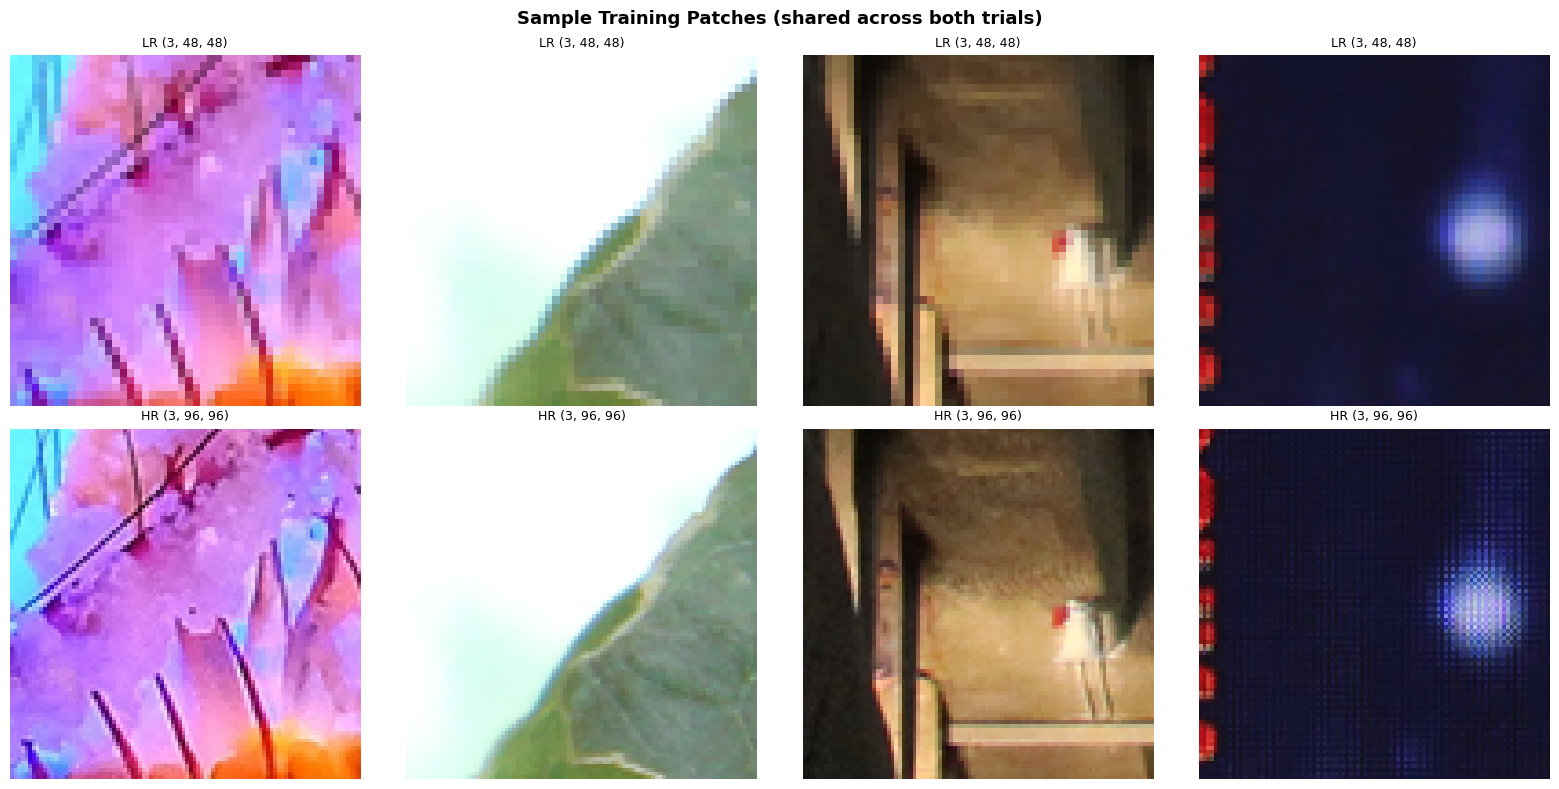

In [7]:
train_dataset = torch.utils.data.ConcatDataset([
    PatchDataset(BASE1 / 'train' / 'hr', BASE1 / 'train' / 'lr'),
    PatchDataset(BASE2 / 'train' / 'hr', BASE2 / 'train' / 'lr'),
])

val_dataset = torch.utils.data.ConcatDataset([
    ValDataset(BASE1 / 'val' / 'hr', BASE1 / 'val' / 'lr'),
    ValDataset(BASE2 / 'val' / 'hr', BASE2 / 'val' / 'lr'),
])

train_loader = DataLoader(
    train_dataset,
    batch_size  = BASE_CONFIG["batch_size"],
    shuffle     = True,
    num_workers = 0,
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 1,
    shuffle     = False,
    num_workers = 0,
)

lr_b, hr_b        = next(iter(train_loader))
lr_v, hr_v, fname = next(iter(val_loader))

print("=" * 52)
print("Data pipeline verification")
print("=" * 52)
print(f"Training patches   : {len(train_dataset):,}")
print(f"Validation patches : {len(val_dataset)}")
print(f"Training batches   : {len(train_loader):,}")
print(f"LR patch shape     : {tuple(lr_b.shape)}")
print(f"HR patch shape     : {tuple(hr_b.shape)}")
print(f"Pixel value range  : [{lr_b.min():.2f}, {lr_b.max():.2f}]")
assert hr_b.shape[-1] == lr_b.shape[-1] * BASE_CONFIG["scale"], "Scale mismatch!"
assert lr_b.shape[-1] == BASE_CONFIG["lr_patch_size"], "LR patch size mismatch!"
print("=" * 52)
print("Data pipeline OK.")
print("\nNote: both trials will use this exact dataset.")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(lr_b[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[0, i].set_title(f"LR {tuple(lr_b[i].shape)}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(hr_b[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].set_title(f"HR {tuple(hr_b[i].shape)}", fontsize=9)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel(f"LR ({BASE_CONFIG['lr_patch_size']}x{BASE_CONFIG['lr_patch_size']})", fontsize=11)
axes[1, 0].set_ylabel(f"HR ({BASE_CONFIG['hr_patch_size']}x{BASE_CONFIG['hr_patch_size']})", fontsize=11)
plt.suptitle("Sample Training Patches (shared across both trials)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_patches.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3 -- Evaluation Metrics

Two standard metrics are used throughout:

**PSNR (Peak Signal-to-Noise Ratio)** measures pixel-level fidelity in dB, higher is better.

**SSIM (Structural Similarity Index)** measures perceptual similarity in terms
of luminance, contrast, and structure, in [0, 1], higher is better.

Both metrics are computed on the Y (luminance) channel of YCbCr, following
standard practice in SR papers.


In [8]:
def rgb_to_y(img: torch.Tensor) -> torch.Tensor:
    squeeze = img.dim() == 3
    if squeeze:
        img = img.unsqueeze(0)
    r, g, b = img[:, 0:1], img[:, 1:2], img[:, 2:3]
    y = 16/255 + (65.481/255)*r + (128.553/255)*g + (24.966/255)*b
    return y.squeeze(0) if squeeze else y


def compute_psnr(sr: torch.Tensor, hr: torch.Tensor, use_y: bool = True) -> float:
    with torch.no_grad():
        if use_y:
            sr, hr = rgb_to_y(sr.float()), rgb_to_y(hr.float())
        mse = F.mse_loss(sr.float(), hr.float())
        if mse == 0:
            return float('inf')
        return (10.0 * torch.log10(torch.tensor(1.0) / mse)).item()


def compute_ssim(sr: torch.Tensor, hr: torch.Tensor, use_y: bool = True) -> float:
    if sr.dim() == 4:
        sr, hr = sr.squeeze(0), hr.squeeze(0)
    if use_y:
        sr_np = rgb_to_y(sr).squeeze(0).detach().numpy()
        hr_np = rgb_to_y(hr).squeeze(0).detach().numpy()
        ch_ax = None
    else:
        sr_np = sr.permute(1, 2, 0).detach().numpy().clip(0, 1)
        hr_np = hr.permute(1, 2, 0).detach().numpy().clip(0, 1)
        ch_ax = 2
    min_dim = min(sr_np.shape[:2])
    win = min(7, min_dim if min_dim % 2 == 1 else min_dim - 1)
    return float(sk_ssim(hr_np, sr_np, data_range=1.0, channel_axis=ch_ax, win_size=win))


def bicubic_upscale(lr: torch.Tensor, scale: int) -> torch.Tensor:
    squeeze = lr.dim() == 3
    if squeeze:
        lr = lr.unsqueeze(0)
    sr = F.interpolate(lr.float(), scale_factor=scale,
                       mode='bicubic', align_corners=False, antialias=True).clamp(0, 1)
    return sr.squeeze(0) if squeeze else sr


# Sanity check
t1 = torch.rand(1, 3, 96, 96)
t2 = torch.rand(1, 3, 96, 96)
print(f"Same tensor -> PSNR: {compute_psnr(t1,t1):.1f} dB  SSIM: {compute_ssim(t1,t1):.4f}")
print(f"Diff tensor -> PSNR: {compute_psnr(t1,t2):.2f} dB  SSIM: {compute_ssim(t1,t2):.4f}")
print("Metric functions defined.")


Same tensor -> PSNR: inf dB  SSIM: 1.0000
Diff tensor -> PSNR: 12.69 dB  SSIM: 0.0308
Metric functions defined.


## Section 4 -- Bicubic Interpolation Baseline

Bicubic interpolation is evaluated once here and reused in both trial
comparisons. It has zero learnable parameters and sets the performance
floor that the learned model must exceed.


In [9]:
def evaluate_bicubic(val_loader, scale: int) -> dict:
    psnr_list, ssim_list, time_list = [], [], []
    for lr, hr, _ in val_loader:
        t0 = time.time()
        sr = bicubic_upscale(lr, scale)
        time_list.append((time.time() - t0) * 1000)
        psnr_list.append(compute_psnr(sr, hr, use_y=True))
        ssim_list.append(compute_ssim(sr.squeeze(0), hr.squeeze(0), use_y=True))
    return {
        "psnr"        : float(np.mean(psnr_list)),
        "ssim"        : float(np.mean(ssim_list)),
        "psnr_std"    : float(np.std(psnr_list)),
        "avg_time_ms" : float(np.mean(time_list)),
    }

print("Evaluating bicubic baseline ...")
bicubic_metrics = evaluate_bicubic(val_loader, BASE_CONFIG["scale"])

print("=" * 52)
print("Bicubic baseline -- validation patches (Y-channel)")
print("=" * 52)
print(f"  PSNR : {bicubic_metrics['psnr']:.4f} dB (+/- {bicubic_metrics['psnr_std']:.4f})")
print(f"  SSIM : {bicubic_metrics['ssim']:.4f}")
print(f"  Time : {bicubic_metrics['avg_time_ms']:.2f} ms per patch")
print("=" * 52)


Evaluating bicubic baseline ...
Bicubic baseline -- validation patches (Y-channel)
  PSNR : 32.4459 dB (+/- 6.1842)
  SSIM : 0.9052
  Time : 8.32 ms per patch


## Section 5 -- IMDN-Lite Architecture

The architecture is identical for both trials. Only the training duration
differs between them.

### Architecture overview

```
Input LR patch  [3, 48, 48]
       |
    HEAD: Conv(3x3) -> [32, 48, 48]
       |
    BODY: 3 x IMDBBlock
    + IIC: concat all intermediate outputs -> Conv(1x1)
       |
    TAIL: Conv(3x3) -> PixelShuffle(2)
       |
Output SR patch [3, 96, 96]
```

### 5.1 Contrast-Aware Channel Attention (CCA)

CCA (Hui et al., 2019, Section 3.2.2) enriches the standard Squeeze-and-Excitation
descriptor with the channel standard deviation, capturing edge and texture energy
that is critical for super-resolution.


In [10]:
class CCALayer(nn.Module):
    """
    Contrast-Aware Channel Attention (Hui et al., 2019, Section 3.2.2).
    """

    def __init__(self, num_features: int, reduction: int = 4):
        super().__init__()
        mid = max(num_features // reduction, 4)
        self.fc = nn.Sequential(
            nn.Conv2d(num_features, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, num_features, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        contrast = x.std(dim=[2, 3], keepdim=True) + x.mean(dim=[2, 3], keepdim=True)
        return x * self.fc(contrast)


class IMDBBlock(nn.Module):
    """
    Information Multi-Distillation Block (Hui et al., 2019, Section 3.2).
    """

    def __init__(self, num_features: int = 32):
        super().__init__()
        self.keep = num_features // 4
        self.rest = num_features - self.keep

        def conv_lrelu(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.LeakyReLU(0.05, inplace=True),
            )

        self.prm1   = conv_lrelu(num_features, num_features)
        self.prm2   = conv_lrelu(self.rest,    num_features)
        self.prm3   = conv_lrelu(self.rest,    num_features)
        self.prm4   = conv_lrelu(self.rest,    self.keep)
        self.cca    = CCALayer(num_features)
        self.fusion = nn.Conv2d(num_features, num_features, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out1 = self.prm1(x);  r1, c1 = torch.split(out1, [self.keep, self.rest], dim=1)
        out2 = self.prm2(c1); r2, c2 = torch.split(out2, [self.keep, self.rest], dim=1)
        out3 = self.prm3(c2); r3, c3 = torch.split(out3, [self.keep, self.rest], dim=1)
        r4   = self.prm4(c3)
        distilled = torch.cat([r1, r2, r3, r4], dim=1)
        return self.fusion(self.cca(distilled)) + residual


class IMDN(nn.Module):
    """
    IMDN-Lite: lightweight single-image super-resolution network.
    Adapted from Hui et al. (2019) with reduced channel width (32 vs 64)
    and block count (3 vs 6) to meet CPU inference constraints.
    """

    def __init__(self, num_features: int = 32, num_blocks: int = 3, scale: int = 2):
        super().__init__()
        self.scale   = scale
        self.head    = nn.Conv2d(3, num_features, 3, padding=1)
        self.body    = nn.ModuleList([IMDBBlock(num_features) for _ in range(num_blocks)])
        self.iic     = nn.Conv2d((num_blocks + 1) * num_features, num_features, 1)
        self.lr_conv = nn.Conv2d(num_features, num_features, 3, padding=1)
        self.tail    = nn.Sequential(
            nn.Conv2d(num_features, 3 * (scale ** 2), 3, padding=1),
            nn.PixelShuffle(scale),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        head_out   = self.head(x)
        iic_inputs = [head_out]
        current    = head_out
        for block in self.body:
            current = block(current)
            iic_inputs.append(current)
        fused = self.lr_conv(self.iic(torch.cat(iic_inputs, dim=1))) + head_out
        return self.tail(fused).clamp(0.0, 1.0)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


set_seed(BASE_CONFIG["seed"])
_test = IMDN(BASE_CONFIG["num_features"], BASE_CONFIG["num_blocks"], BASE_CONFIG["scale"])
_d    = torch.zeros(1, 3, BASE_CONFIG["lr_patch_size"], BASE_CONFIG["lr_patch_size"])
with torch.no_grad():
    _o = _test(_d)
assert tuple(_o.shape) == (1, 3, BASE_CONFIG["hr_patch_size"], BASE_CONFIG["hr_patch_size"])
print(f"Architecture verified.")
print(f"Trainable parameters : {_test.count_parameters():,}")
print(f"Forward pass : {tuple(_d.shape)} -> {tuple(_o.shape)}")
del _test, _d, _o


Seed fixed to 42.
Architecture verified.
Trainable parameters : 97,060
Forward pass : (1, 3, 48, 48) -> (1, 3, 96, 96)


## Section 6 -- Training Both Trials

Both trials are executed sequentially. For each trial:

1. A fresh model is initialised from the same seed.
2. The model is trained for `max_steps` steps using the shared CONFIG.
3. The best checkpoint (highest validation PSNR) is saved under a trial-specific directory.
4. All results are stored in `all_results` for the cross-trial comparison in Section 7.

### 6.1 Training Utilities


In [11]:
def validate_model(model, val_loader, scale: int) -> dict:
    """
    Evaluate on the full validation patch set.
    Since validation data consists of pre-cut 96x96 patches, each patch is
    passed through the model in full -- no cropping needed.
    """
    model.eval()
    psnr_list, ssim_list, time_list = [], [], []
    with torch.no_grad():
        for lr, hr, _ in val_loader:
            t0 = time.time()
            sr = model(lr)
            time_list.append((time.time() - t0) * 1000)
            psnr_list.append(compute_psnr(sr, hr, use_y=True))
            ssim_list.append(compute_ssim(sr.squeeze(0), hr.squeeze(0), use_y=True))
    return {
        "psnr"        : float(np.mean(psnr_list)),
        "ssim"        : float(np.mean(ssim_list)),
        "psnr_std"    : float(np.std(psnr_list)),
        "avg_time_ms" : float(np.mean(time_list)),
    }


def run_trial(trial_cfg: dict, base_cfg: dict, train_loader, val_loader) -> dict:
    """
    Train one IMDN-Lite model for a fixed number of steps and return results.

    Args:
        trial_cfg : Dict with keys 'name' and 'max_steps'.
        base_cfg  : Shared hyperparameter dictionary.
        train_loader, val_loader: DataLoaders (shared across trials).

    Returns:
        Dictionary with training history, best metrics, and timing.
    """
    name      = trial_cfg["name"]
    max_steps = trial_cfg["max_steps"]
    ckpt_dir  = f"checkpoints/{name}"
    os.makedirs(ckpt_dir, exist_ok=True)

    set_seed(base_cfg["seed"])
    model     = IMDN(base_cfg["num_features"], base_cfg["num_blocks"], base_cfg["scale"])
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=base_cfg["learning_rate"], betas=(0.9, 0.999))

    history    = {"train_loss": [], "train_psnr": [], "val_psnr": [], "val_ssim": [], "step": []}
    best_psnr  = 0.0
    best_step  = 0
    best_state = None
    current_lr = base_cfg["learning_rate"]
    start_time = time.time()

    VALIDATE_EVERY = max(10, max_steps // 10)

    print("=" * 72)
    print(f"Trial: {name}  |  max_steps={max_steps}")
    print(f"Bicubic baseline: {bicubic_metrics['psnr']:.4f} dB  (target to exceed)")
    print("=" * 72)

    global_step = 0
    while global_step < max_steps:
        for lr_batch, hr_batch in train_loader:
            if global_step >= max_steps:
                break

            if global_step > 0 and global_step % base_cfg["lr_decay_steps"] == 0:
                current_lr *= base_cfg["lr_decay_factor"]
                for pg in optimizer.param_groups:
                    pg['lr'] = current_lr
                print(f"  LR decayed to {current_lr:.2e} at step {global_step}.")

            model.train()
            sr   = model(lr_batch)
            loss = criterion(sr, hr_batch)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), base_cfg["grad_clip"])
            optimizer.step()
            global_step += 1

            if global_step % VALIDATE_EVERY == 0 or global_step == max_steps:
                val_m = validate_model(model, val_loader, base_cfg["scale"])
                with torch.no_grad():
                    train_psnr = compute_psnr(sr.detach(), hr_batch, use_y=False)

                history["train_loss"].append(loss.item())
                history["train_psnr"].append(train_psnr)
                history["val_psnr"].append(val_m["psnr"])
                history["val_ssim"].append(val_m["ssim"])
                history["step"].append(global_step)

                if val_m["psnr"] > best_psnr:
                    best_psnr  = val_m["psnr"]
                    best_step  = global_step
                    best_state = {k: v.cpu().clone() if hasattr(v, 'clone') else v
                                  for k, v in model.state_dict().items()}
                    torch.save({"step": global_step, "model_state": model.state_dict(),
                                "metrics": val_m},
                               f"{ckpt_dir}/best_model.pth")

                elapsed = (time.time() - start_time) / 60
                marker  = "  [best]" if val_m["psnr"] == best_psnr else ""
                print(f"  Step [{global_step:4d}/{max_steps}]  "
                      f"Loss: {loss.item():.5f}  "
                      f"Val PSNR: {val_m['psnr']:6.3f} dB  "
                      f"Val SSIM: {val_m['ssim']:.4f}  "
                      f"{elapsed:.1f} min{marker}")

    total_time = (time.time() - start_time) / 60
    gain = best_psnr - bicubic_metrics['psnr']
    print(f"\nTrial {name} complete in {total_time:.1f} min.")
    print(f"  Best PSNR : {best_psnr:.4f} dB (step {best_step})")
    print(f"  Gain      : {gain:+.4f} dB vs bicubic")

    model.load_state_dict(best_state)
    final_metrics = validate_model(model, val_loader, base_cfg["scale"])

    return {
        "name"          : name,
        "max_steps"     : max_steps,
        "history"       : history,
        "best_psnr"     : best_psnr,
        "best_step"     : best_step,
        "final_metrics" : final_metrics,
        "time_minutes"  : round(total_time, 2),
        "model"         : model,
    }

print("Training utilities defined.")


Training utilities defined.


### 6.2 Execute Both Trials

The cell below runs Trial 1 (100 steps) followed by Trial 2 (200 steps).
Each trial starts from the same random seed, so any difference in results
is attributable solely to the number of training steps.


In [ ]:
all_results = []

for trial_cfg in TRIALS:
    result = run_trial(trial_cfg, BASE_CONFIG, train_loader, val_loader)
    all_results.append(result)
    print()

print("Both trials complete.")


Seed fixed to 42.
Trial: trial_100_steps  |  max_steps=100
Bicubic baseline: 32.4459 dB  (target to exceed)


## Section 7 -- Results and Comparison

### 7.1 Training Curves


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["steelblue", "darkorange"]

for res, color in zip(all_results, colors):
    steps = res["history"]["step"]
    label = res["name"].replace("_", " ")
    axes[0].plot(steps, res["history"]["train_loss"], color=color, lw=2, label=label)
    axes[1].plot(steps, res["history"]["val_psnr"],   color=color, lw=2, label=label)
    axes[2].plot(steps, res["history"]["val_ssim"],   color=color, lw=2, label=label)

axes[1].axhline(bicubic_metrics["psnr"], color="red", ls="--", lw=1.5,
                label=f"Bicubic {bicubic_metrics['psnr']:.2f} dB")
axes[2].axhline(bicubic_metrics["ssim"], color="red", ls="--", lw=1.5,
                label=f"Bicubic {bicubic_metrics['ssim']:.4f}")

for ax, ylabel, title in zip(axes,
    ["L1 Loss", "PSNR (dB)", "SSIM"],
    ["Training Loss (L1)", "Validation PSNR", "Validation SSIM"]):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Training Curves -- Trial 1 (100 steps) vs Trial 2 (200 steps)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved.")


### 7.2 Summary Comparison Table

In [ ]:
print("=" * 76)
print("Results summary -- validation patches, Y-channel metrics")
print("=" * 76)
print(f"{'Method':<28} {'Steps':>6} {'PSNR (dB)':>10} {'SSIM':>8} {'Time (min)':>12}")
print("-" * 76)
print(f"{'Bicubic (baseline)':<28} {'--':>6} "
      f"{bicubic_metrics['psnr']:>10.4f} "
      f"{bicubic_metrics['ssim']:>8.4f} {'--':>12}")

for res in all_results:
    fm   = res["final_metrics"]
    name = res["name"].replace("_", " ")
    print(f"  {'IMDN-Lite ' + name:<26} {res['max_steps']:>6} "
          f"{fm['psnr']:>10.4f} "
          f"{fm['ssim']:>8.4f} "
          f"{res['time_minutes']:>12.2f}")

print("-" * 76)
print("\nGain over bicubic baseline:")
for res in all_results:
    fm   = res["final_metrics"]
    name = res["name"].replace("_", " ")
    print(f"  {name:<30} PSNR {fm['psnr'] - bicubic_metrics['psnr']:+.4f} dB  "
          f"SSIM {fm['ssim'] - bicubic_metrics['ssim']:+.4f}")

if len(all_results) == 2:
    r1, r2 = all_results[0]["final_metrics"], all_results[1]["final_metrics"]
    print(f"\nGain of 200 steps over 100 steps:")
    print(f"  PSNR {r2['psnr'] - r1['psnr']:+.4f} dB")
    print(f"  SSIM {r2['ssim'] - r1['ssim']:+.4f}")
print("=" * 76)


### 7.3 Visual Comparison

In [ ]:
N_SHOW  = min(3, len(val_dataset))
samples = list(val_loader)[:N_SHOW]

fig, axes = plt.subplots(N_SHOW, 4,
                          figsize=(17, 4.2 * N_SHOW),
                          gridspec_kw={"hspace": 0.4, "wspace": 0.05})

col_titles = [
    "Bicubic (Baseline)",
    f"IMDN-Lite {all_results[0]['name'].replace('_',' ')}",
    f"IMDN-Lite {all_results[1]['name'].replace('_',' ')}",
    "Ground Truth (HR)",
]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight="bold", pad=8)

model_t1 = all_results[0]["model"]
model_t2 = all_results[1]["model"]
model_t1.eval(); model_t2.eval()

for row, (lr, hr, fname) in enumerate(samples):
    with torch.no_grad():
        sr_bic = bicubic_upscale(lr, BASE_CONFIG["scale"])
        sr_t1  = model_t1(lr)
        sr_t2  = model_t2(lr)

    def to_img(t):
        return t.squeeze(0).permute(1, 2, 0).numpy().clip(0, 1)

    psnr_bic = compute_psnr(sr_bic, hr, use_y=True)
    psnr_t1  = compute_psnr(sr_t1,  hr, use_y=True)
    psnr_t2  = compute_psnr(sr_t2,  hr, use_y=True)

    for col, (img, label) in enumerate([
        (to_img(sr_bic), f"PSNR: {psnr_bic:.2f} dB"),
        (to_img(sr_t1),  f"PSNR: {psnr_t1:.2f} dB"),
        (to_img(sr_t2),  f"PSNR: {psnr_t2:.2f} dB"),
        (to_img(hr),     "Ground Truth"),
    ]):
        axes[row, col].imshow(img, interpolation="nearest")
        axes[row, col].set_xlabel(label, fontsize=9)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    axes[row, 0].set_ylabel(f"Patch: {fname[0]}", fontsize=10)

plt.suptitle("Visual Comparison -- 100 steps vs 200 steps vs Bicubic",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("visual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visual comparison saved.")


### 7.4 Save All Results

In [ ]:
summary = {
    "base_config"   : BASE_CONFIG,
    "trials"        : TRIALS,
    "bicubic"       : bicubic_metrics,
    "trial_results" : [
        {
            "name"                 : r["name"],
            "max_steps"            : r["max_steps"],
            "best_step"            : r["best_step"],
            "best_psnr"            : r["best_psnr"],
            "final_metrics"        : r["final_metrics"],
            "time_minutes"         : r["time_minutes"],
            "psnr_gain_vs_bicubic" : r["final_metrics"]["psnr"] - bicubic_metrics["psnr"],
        }
        for r in all_results
    ],
}

if len(all_results) == 2:
    summary["psnr_gain_200_over_100"] = (
        all_results[1]["final_metrics"]["psnr"] - all_results[0]["final_metrics"]["psnr"]
    )

os.makedirs("results", exist_ok=True)
with open("results/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Results saved to results/results_summary.json.")
